In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

<h3>Plot the counterfactual radiuses against training set size to obtain the primary result of our study</h3>

In [2]:
# Load all counterfactual radiuses
df = pd.read_csv("../data/counterfactual_radius.csv")

# Show the CR measured in Euclidean Distance
df = df.set_index("Distance Metric").loc["Euclidean Distance"].reset_index(drop=True)
# Discard the control conditions
df = df.set_index("Group").loc["Primary"].reset_index(drop=True)

In [3]:
training_set_size = df["Training Set Size"]
mean_counterfactual_radius = df.drop(["Ensemble/Model", "Training Set Size"], axis=1).mean(axis=1)

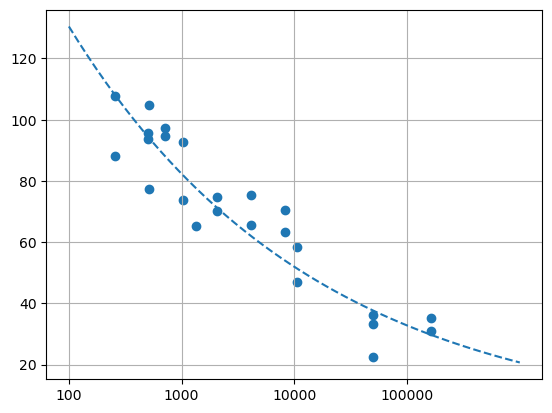

Intercept: 327.66, Slope: -0.20


In [4]:
# Power law
slope, intercept = np.polyfit(np.log(training_set_size), np.log(mean_counterfactual_radius), 1)
intercept = np.exp(intercept)

# Plot with x on log scale
plt.scatter(np.log(training_set_size)/np.log(10), mean_counterfactual_radius)
trend_x_log_space = np.linspace(2, 6)
plt.plot(trend_x_log_space, intercept * 10**(trend_x_log_space*slope), linestyle='--')
plt.xticks([2, 3, 4, 5], [100, 1000, 10000, 100000])
plt.grid()
plt.show()
print (f"Intercept: {intercept:.2f}, Slope: {slope:.2f}")

<h3>Plot the false attribution rate against training set size</h3>

In [5]:
# Load all counterfactual radiuses
df = pd.read_csv("../data/false_attribution.csv")

# Show the attributions measured in Euclidean Distance
df = df.set_index("Attribution Method").loc["Euclidean Distance"].reset_index(drop=True)
# Extract the MNIST trajectory
df = df.set_index("Group").loc["MNIST"].reset_index(drop=True)

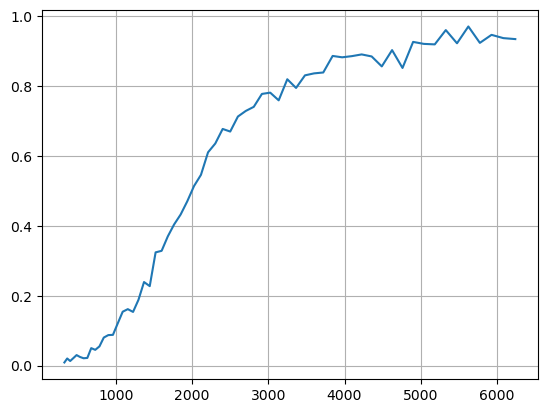

In [6]:
p1 = df["Attribution Unchanged"]/(df["Attribution Unchanged"]+df["Attribution Changed"])
p2 = df["Attribution Unchanged (Random)"]/(df["Attribution Unchanged (Random)"]+df["Attribution Changed (Random)"])
false_attribution_rate = (p1/p2).clip(0,1)
training_set_size = df["Ensemble"].map(lambda x: int(x.split('_')[-1]))
plt.plot(training_set_size, false_attribution_rate)
plt.grid()
plt.show()